## Remove intrument response

In [1]:
### REMOVE INSTRUMENTAL RESPONSE FROM DOWNLOADED WAVEFORMS WITH STATION.XML
### AND SAVE NEW-WAVEFORMS IN NEW DIRECTORY 

import os
from obspy import read, read_inventory
workdir='../'

# lpad stations.xml
stations_name= workdir + 'META_DATA/stations_flegrei_INGV_final.xml'        #CHANGE
xml_name=stations_name.split('/')[-1]
stations=read_inventory(stations_name)  
print('loading station xml:',xml_name)

# load wavelet (obspy)
ev_name= workdir + 'DATA/flegrei_2023_06_11_06_44_25/flegrei_2023_06_11_06_44_25.mseed'     #CHANGE 
w_name=ev_name.split('/')[-1]
w=read(ev_name)
print('loading event:',w_name)

#wave.merge(fill_value=0)

# trim over the [t1, t2] interval
#wave.trim(starttime=event_start, endtime=event_end, pad=True, fill_value=0)

# remove trend
w.detrend("demean")

# pre-filtering
pre_filt = [0.005, 0.01, 45,50]       

# remove instrumental response
w.remove_response(
    inventory=stations,
    output="VEL",
    pre_filt=pre_filt
)

# save
wavelet_name= w_name.split('.')[0] + '_response_removed'            #CHANGE
w.write( wavelet_name +'.mseed',format='MSEED')
print('response removed and saved!')


loading station xml: stations_flegrei_INGV_final.xml
loading event: flegrei_2023_06_11_06_44_25.mseed
response removed and saved!


/opt/homebrew/lib/python3.11/site-packages/obspy/io/mseed/core.py:770: UserWarning: The encoding specified in trace.stats.mseed.encoding does not match the dtype of the data.
A suitable encoding will be chosen.
  warnings.warn(msg, UserWarning)


## Read XML

In [2]:
from obspy import read_inventory
path="/Users/giaco/UNI/PhD_CODE/GIT/Grond_composite_test/META_DATA/stations_flegrei_INGV_flat_response.xml"
inv = read_inventory(path,format="STATIONXML")
inv

Inventory created at 2024-01-16T14:42:48.667000Z
	Created by: INGV-ONT WEB SERVICE: fdsnws-station | version: 1.1.57
		    /exist/apps/fdsn-station/fdsnws/station/1/query?starttime=2014-01-...
	Sending institution: eXistDB (INGV-ONT)
	Contains:
		Networks (1):
			IV
		Stations (20):
			IV.CAAM (Accademia Aeronautica Pozzuoli)
			IV.CBAC (Campi Flegrei, Castello di Baia - Stazione Osservatorio Vesu)
			IV.CFMN (Monte Nuovo)
			IV.CMIS (Faro di Capo Miseno - Stazione Osservatorio Vesuviano)
			IV.CMSN (Monte S.Angelo)
			IV.CMTS (Campi Flegrei, Via Metastasio CNR-IRC)
			IV.CNIS (Campi Flegrei - Isola di Nisida)
			IV.COLB (Campi Flegrei, Galleria Monte Olibano, Stazione Osservatorio)
			IV.CPIS (Campi Flegrei - Fumarola Pisciarelli)
			IV.CPOZ (Darsena Pozzuoli - Stazione Osservatorio Vesuviano)
			IV.CQUE (Campi Flegrei Quarto EST - Stazione Osservatorio Vesuviano)
			IV.CSFT (Campi Flegrei - Cratere Solfatara, Interno)
			IV.CSOB (Solfatara Bordo Cratere - Stazione Osservatorio Vesuvi

### Plot instrument response

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Station: Station CAAM (Accademia Aeronautica Pozzuoli)
	Station Code: CAAM
	Channel Count: 9/9 (Selected/Total)
	2011-12-09T23:00:00.000000Z - 
	Access: open 
	Latitude: 40.8201, Longitude: 14.1420, Elevation: 170.0 m
	Available Channels:
	    ..HN[ZNE]   200.0 Hz  2022-02-25 to None
	    ..HH[ZNE]   100.0 Hz  2022-02-25 to None
	    ..HH[ZNE]   100.0 Hz  2011-12-09 to 2022-02-25

Channel: HHE


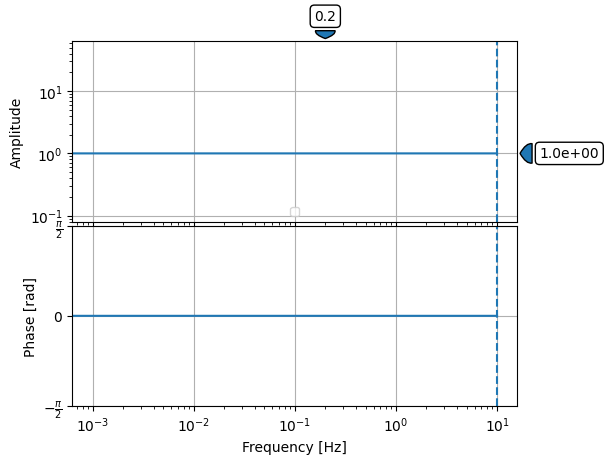

In [3]:
net=0
st=0
ch=0
resp = inv[net][st][ch].response
print(f'Station: {inv[net][st]}')
print(f'Channel: {inv[net][st][ch].code}')
resp.plot(0.001,sampling_rate=20.);

# ------
# Extras
# ------


In [21]:
from pyrocko.gf import LocalEngine, Target, DCSource, ws,MTSource

store_id = 'campiflegrei_near_0_dist'

engine = LocalEngine(store_superdirs=['../GF_STORES'])

store = engine.get_store(store_id)
print(store.config.__dict__)

{'_do_auto_updates': True, 'id': 'campiflegrei_near_0_dist', 'derived_from_id': None, 'version': '1.0', 'modelling_code_id': 'qseis.2006b', 'author': None, 'author_email': None, 'created_time': None, 'regions': [], 'scope_type': None, 'waveform_type': None, 'nearfield_terms': None, 'description': None, 'references': [], 'earthmodel_1d': <pyrocko.cake.LayeredModel object at 0x16a633850>, 'earthmodel_receiver_1d': None, 'can_interpolate_source': None, 'can_interpolate_receiver': None, 'frequency_min': None, 'frequency_max': None, 'sample_rate': 20.0, 'factor': 1.0, 'component_scheme': 'elastic10', 'stored_quantity': None, 'tabulated_phases': [<pyrocko.gf.meta.TPDef object at 0x16a632710>, <pyrocko.gf.meta.TPDef object at 0x16a633cd0>, <pyrocko.gf.meta.TPDef object at 0x16a633b10>, <pyrocko.gf.meta.TPDef object at 0x16a630110>], 'ncomponents': 10, 'uuid': None, 'reference': None, 'receiver_depth': 0.0, 'source_depth_min': 100.0, 'source_depth_max': 8000.0, 'source_depth_delta': 100.0, 'di

In [ ]:
from pyrocko import gf,trace,model,util,io

file_name= '../DATA/flegrei_2023_06_11_06_44_25/flegrei_2023_06_11_06_44_25.mseed'
trs = io.load(file_name)

trs[0].__dict__


{'_growbuffer': None,
 'network': 'IV',
 'station': 'CAAM',
 'location': '',
 'channel': 'HHE',
 'extra': '',
 'tmin': 1686465565.72,
 'deltat': 0.01,
 'tmax': 1686466165.72,
 'meta': {'offset_start': 0, 'offset_end': 0, 'last': True, 'segment_size': 0},
 'ydata': array([ 4052,  3515,  2874, ...,  -745, -1328, -1414], dtype=int32),
 'mtime': 1770041057,
 'full_id': ('IV', 'CAAM', '', 'HHE', 1686465565.72),
 'nslc_id': ('IV', 'CAAM', '', 'HHE'),
 'file': None,
 '_pchain': None}

# ---
# TEST CODE
# ---

In [39]:
from pyrocko import moment_tensor as pmt
import numpy as num

r2d = 180. / num.pi

magnitude = 2.926  # Magnitude of the earthquake

exp = pmt.magnitude_to_moment(magnitude)  # convert the mag to moment in [Nm]

# init pyrocko moment tensor
m = pmt.MomentTensor(
    mnn= -num.sqrt(2/3)*exp,
    mee= -num.sqrt(2/3)*exp,
    mdd= -num.sqrt(2/3)*exp,
    mne=0,
    mnd=0,
    med=0)

print(f'M_iso : {-num.sqrt(2/3)*exp}')
print(m)  # print moment tensor

# gives out both nodal planes:
(s1, d1, r1), (s2, d2, r2) = m.both_strike_dip_rake()

#print('strike1=%g, dip1=%g, rake1=%g' % (s1, d1, r1))
#print('strike2=%g, dip2=%g, rake2=%g' % (s2, d2, r2))


# p-axis normal vector in north-east-down coordinates
#p_ned = m.p_axis()

#print('p_ned=(%g, %g, %g)' % tuple(p_ned))

# convert to azimuth and dip
#p_azimuth = num.arctan2(p_ned[1], p_ned[0]) * r2d
#p_dip = num.arcsin(p_ned[2]) * r2d

#print('p_azimuth=%g, p_dip=%g' % (p_azimuth, p_dip))


M_iso : -22436461807593.97
Scalar Moment [Nm]: M0 = 2.74789e+13 (Mw = 2.9)
Moment Tensor [Nm]: Mnn = -0.224,  Mee = -0.224, Mdd = -0.224,
                    Mne =  0.000,  Mnd =  0.000, Med =  0.000    [ x 1e+14 ]
Fault plane 1 [deg]: strike = 270, dip =  45, slip-rake =   90
Fault plane 2 [deg]: strike =  90, dip =  45, slip-rake =   90

